# Import Libraries

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

# MultiLayerNN class Implementation

In [2]:
class MultiLayerNN:
    def __init__(self, layer_sizes, learning_rate=0.01, iterations=10000):
        self.lr = learning_rate
        self.iterations = iterations
        self.layer_sizes = layer_sizes
        self.cost_history = []
        self.weights = []
        self.biases = []

        # Initialize weights and biases for each layer
        for i in range(len(layer_sizes) - 1):
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * 0.01)
            self.biases.append(np.zeros((1, layer_sizes[i + 1])))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def sigmoid_derivative(self, z):
        s = self.sigmoid(z)
        return s * (1 - s)

    def forward(self, X):
        self.activations = [X]
        self.z_values = []

        current = X
        for i in range(len(self.weights)):
            z = np.dot(current, self.weights[i]) + self.biases[i]
            self.z_values.append(z)
            current = self.sigmoid(z)
            self.activations.append(current)

        return self.activations[-1]

    def backward(self, y):
        m = y.shape[0]
        weight_grads = [None] * len(self.weights)
        bias_grads = [None] * len(self.biases)

        # Output layer error
        delta = self.activations[-1] - y

        # Backpropagate through each layer
        for i in reversed(range(len(self.weights))):
            weight_grads[i] = (1 / m) * np.dot(self.activations[i].T, delta)
            bias_grads[i] = (1 / m) * np.sum(delta, axis=0, keepdims=True)

            if i > 0:
                delta = np.dot(delta, self.weights[i].T) * self.sigmoid_derivative(self.z_values[i - 1])

        return weight_grads, bias_grads

    def cost(self, y_pred, y_true):
        return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

    def fit(self, X, y):
        y = y.reshape(-1, 1)

        for i in range(self.iterations):
            y_pred = self.forward(X)
            weight_grads, bias_grads = self.backward(y)

            for j in range(len(self.weights)):
                self.weights[j] -= self.lr * weight_grads[j]
                self.biases[j] -= self.lr * bias_grads[j]

            self.cost_history.append(self.cost(y_pred, y))

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

# Prepare Data

In [3]:
# Generate concentric circles (non-linearly separable)
np.random.seed(42)
X, y = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the Model

In [4]:
# 2 -> 8 -> 8 -> 1 (two hidden layers)
model = MultiLayerNN(layer_sizes=[2, 8, 8, 1], learning_rate=0.5, iterations=8000)
model.fit(X_train, y_train)

# Evaluate the Model

In [5]:
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred.flatten() == y_test)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.43


# Visualize Results

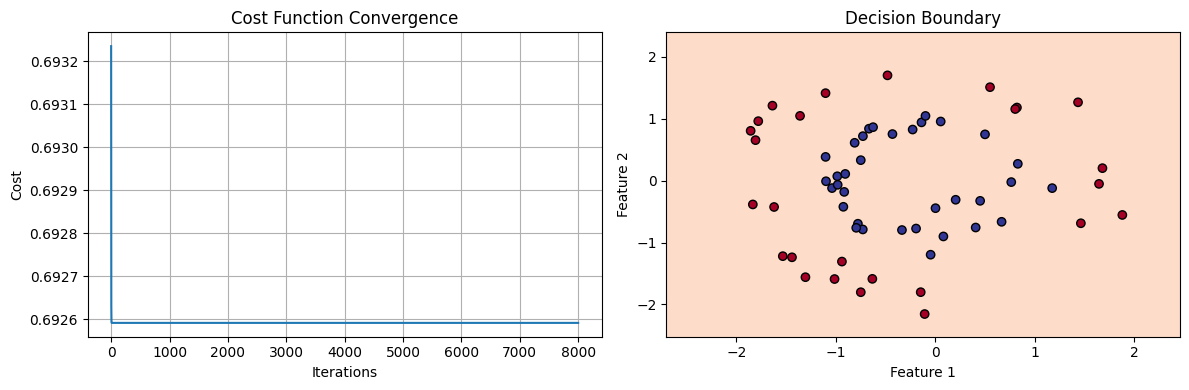

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(model.cost_history)
axes[0].set_title('Cost Function Convergence')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Cost')
axes[0].grid(True)

xx, yy = np.meshgrid(
    np.linspace(X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5, 200),
    np.linspace(X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='RdYlBu')
axes[1].set_title('Decision Boundary')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()